In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/projects/olist

/content/drive/MyDrive/projects/olist


# Project Overview

This notebook builds an **end-to-end customer intelligence system** using the **Brazilian Olist E-Commerce dataset** (Kaggle).
We combine **RFM Segmentation**, **K-Means Clustering**, and **Machine Learning (CLV Prediction)** to identify high-value customers and generate actionable marketing strategies.

**Why Olist?** It is a real-world, multi-table transactional dataset with 100k+ orders across 8 relational tables — closely mirroring production e-commerce data.

### Pipeline:
```
Raw Data → Cleaning → EDA → RFM Analysis → K-Means Clustering → CLV Prediction → Business Recommendations
```

### Dataset
Download from Kaggle: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  

Required files: olist_orders_dataset.csv, olist_order_items_dataset.csv, olist_customers_dataset.csv, olist_order_payments_dataset.csv

In [ ]:
# ── Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Statistics
from scipy import stats
from scipy.stats import shapiro, kruskal, mannwhitneyu

# ── Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})


##  Section 2 — Data Loading & Merging

###  Statistical Context
The Olist dataset is **relational** — we must JOIN multiple tables before analysis.  

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')

print(f'Orders:{orders.shape}')
print(f'Items: {items.shape}')
print(f'Customers: {customers.shape}')
print(f'Payments:  {payments.shape}')

Orders:(99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments:  (103886, 5)


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
is_unique = payments['order_id'].is_unique
print(f"Are order_ids in payments DataFrame unique? {is_unique}")

Are order_ids in payments DataFrame unique? False


In [ ]:
# 1: aggregate items (revenue per order)
items_agg = items.groupby('order_id').agg(revenue=('price', 'sum'), n_items=('order_item_id', 'count')).reset_index()


# 2: aggregate payments (total payment per order)
payments_agg = (payments.groupby('order_id').agg(payment_value=('payment_value', 'sum')).reset_index())

# 3: merge all
df = (
    orders
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

print(f'shape: {df.shape}')
df.head(3)



shape: (99441, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,revenue,n_items,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,29.99,1.00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,118.70,1.00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,159.90,1.00,179.12


## Section 3 — Data Cleaning
  
Key checks:  
- **Missing values** — structural (order never delivered) vs random (data entry errors)
- **Date parsing** — string → datetime

- **Order status filter** — only **delivered** orders represent completed transactions

In [ ]:
# ── Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
display(missing_df[missing_df['missing_count'] > 0])

,missing_count,missing_%
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98
revenue,775,0.78
n_items,775,0.78
payment_value,1,0.00


In [ ]:
#  dates
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#  Keep only DELIVERED orders with non-null revenue
df_clean = (
    df
    .query("order_status == 'delivered'")
    .dropna(subset=['revenue', 'order_purchase_timestamp', 'customer_unique_id'])
    .copy()
)

#  Remove negative/zero revenue (cancellations / data errors)
df_clean = df_clean[df_clean['revenue'] > 0]

print(f'Clean rows: {len(df_clean):,}  (from {len(df):,} raw rows)')
print(f'Unique customers: {df_clean["customer_unique_id"].nunique():,}')
print(f'Date range: {df_clean["order_purchase_timestamp"].min().date()} → {df_clean["order_purchase_timestamp"].max().date()}')

Clean rows: 96,478  (from 99,441 raw rows)
Unique customers: 93,358
Date range: 2016-09-15 → 2018-08-29


##  Section 4 — Exploratory Data Analysis (EDA)

 **descriptive statistics** and **visualisations** to understand distributions before modelling.  
- **Skewness**: Values > 1 indicate right-skewed distributions (common in revenue data)  
- **Kurtosis**: Values > 3 indicate heavy tails (leptokurtic) — outlier-prone  
- **IQR method**: Outliers defined as Q1(the first quartile) − 1.5×IQR or Q3(the third quartile) + 1.5×IQR

In [ ]:
# ── Revenue distribution statistics
rev = df_clean['revenue']

print('=== Revenue Descriptive Statistics ===')
print(f'  Mean:     R$ {rev.mean():.2f}')
print(f'  Median:   R$ {rev.median():.2f}')
print(f'  Std Dev:  R$ {rev.std():.2f}')
print(f'  Skewness: {rev.skew():.3f}  (> 0 → right skew)')
print(f'  Kurtosis: {rev.kurtosis():.3f}  (> 3 heavy tails)')
print(f'  Q1:       R$ {rev.quantile(0.25):.2f}')
print(f'  Q3:       R$ {rev.quantile(0.75):.2f}')
print(f'  IQR:      R$ {rev.quantile(0.75) - rev.quantile(0.25):.2f}')

=== Revenue Descriptive Statistics ===
  Mean:     R$ 137.04
  Median:   R$ 86.57
  Std Dev:  R$ 209.05
  Skewness: 9.886  (> 0 → right skew)
  Kurtosis: 277.012  (> 3 heavy tails)
  Q1:       R$ 45.90
  Q3:       R$ 149.90
  IQR:      R$ 104.00


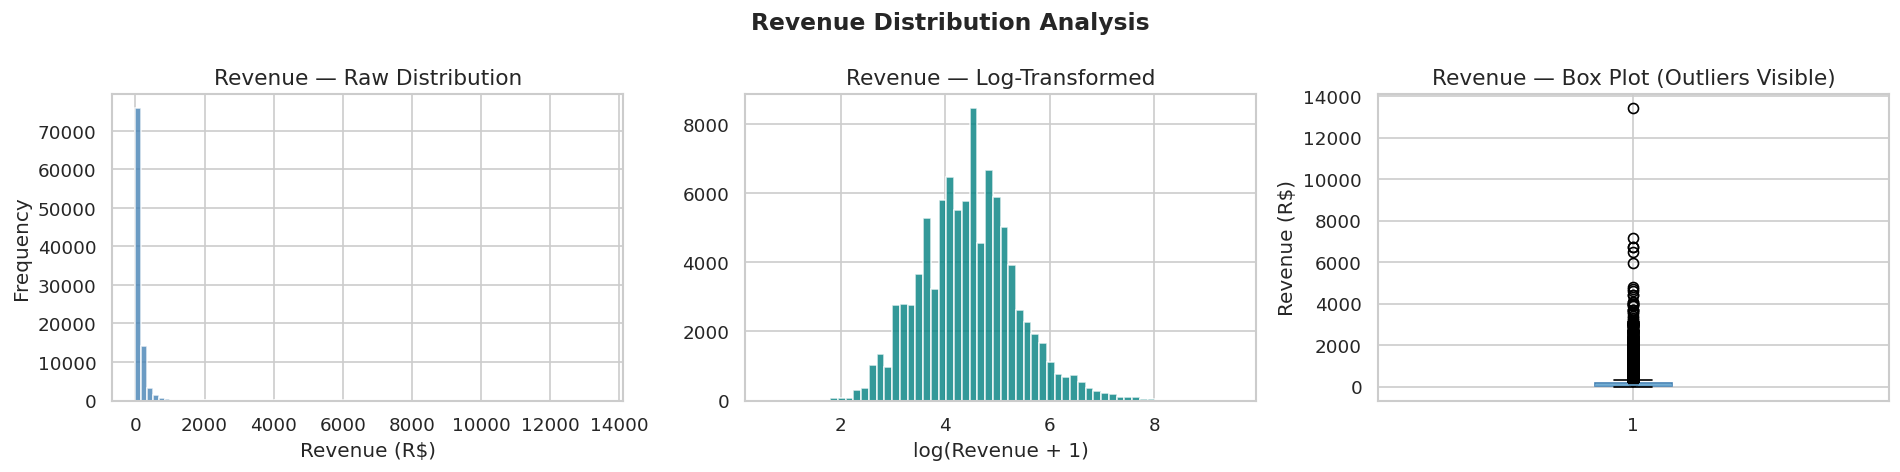

In [ ]:
# Revenue distribution plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw histogram
axes[0].hist(rev, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Revenue — Raw Distribution')
axes[0].set_xlabel('Revenue (R$)')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(rev), bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Revenue — Log-Transformed')
axes[1].set_xlabel('log(Revenue + 1)')

# Box plot
axes[2].boxplot(rev, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[2].set_title('Revenue — Box Plot (Outliers Visible)')
axes[2].set_ylabel('Revenue (R$)')

plt.suptitle('Revenue Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



**Interpretation:**

   - Strong right skew (long tail) is typical in e-commerce data
   - Log transformation normalises the distribution — useful for regression - models.
   - Outliers (very high-value orders) are real signals, not errors — handle carefully.







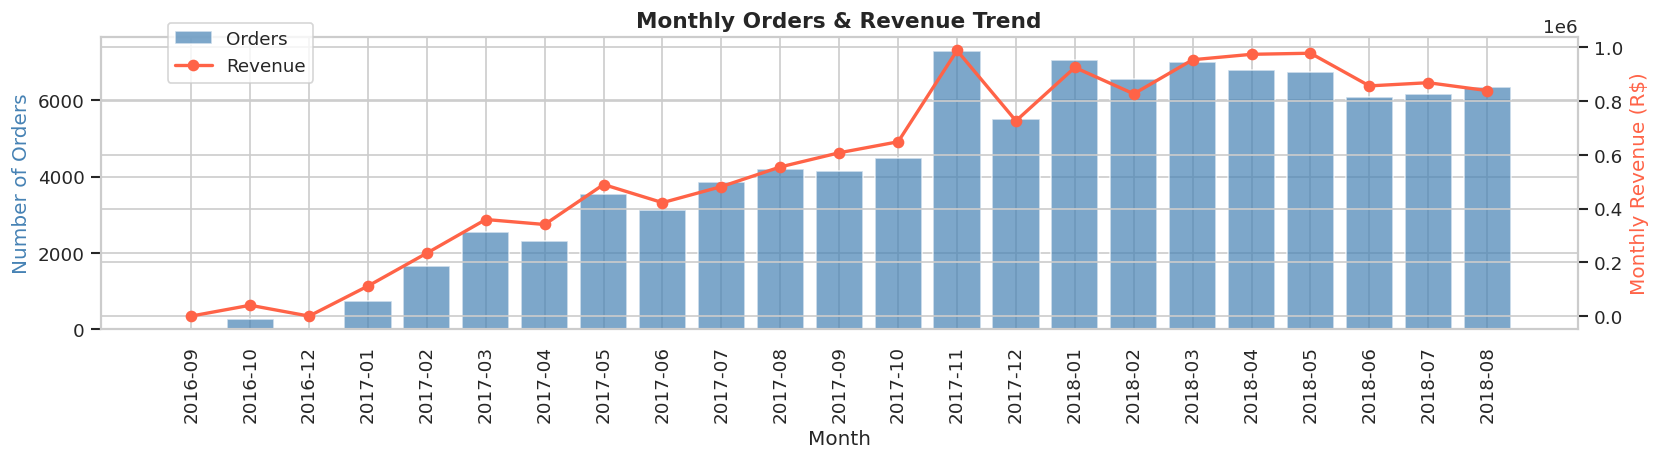

In [ ]:
#  Orders over time
df_clean['month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')
monthly = df_clean.groupby('month').agg(orders=('order_id', 'count'), revenue=('revenue', 'sum')).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['month_str'], monthly['orders'], color='steelblue', alpha=0.7, label='Orders')
ax2.plot(monthly['month_str'], monthly['revenue'], color='tomato', linewidth=2, marker='o', label='Revenue')
ax1.set_ylabel('Number of Orders', color='steelblue')
ax2.set_ylabel('Monthly Revenue (R$)', color='tomato')
ax1.set_xlabel('Month')
ax1.set_xticks(range(len(monthly['month_str'])))
ax1.set_xticklabels(monthly['month_str'], rotation=90)
plt.title('Monthly Orders & Revenue Trend', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

## Section 5 — RFM Feature Engineering

### Statistical Context

RFM transforms raw transactions into **three behavioural signals** per customer:

| Feature | Definition | Business Meaning |
|---------|-----------|------------------|
| **Recency (R)** | Days since last purchase | Engagement freshness — lower = more engaged |
| **Frequency (F)** | Number of unique orders | Loyalty — higher = more loyal |
| **Monetary (M)** | Average order value | Spending tier — higher = higher value |

> **Note on Recency directionality**: Unlike F and M (higher = better), **lower Recency is better**.  
> We account for this during scoring by reversing the rank direction.

In [ ]:
# Reference date: day after last transaction in dataset
snapshot_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (analysis reference): {snapshot_date.date()}')

# Build RFM table
rfm = (
    df_clean.groupby('customer_unique_id')
    .agg(
        last_purchase=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),      # unique orders
        monetary=('revenue', 'mean')            # average order value - (behaviour signal)
                                                # clv sum (total value)
    )
    .reset_index()
)

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days
rfm = rfm.drop(columns=['last_purchase'])

print(f'\nRFM table: {rfm.shape}')
rfm.describe().round(2)

Snapshot date (analysis reference): 2018-08-30

RFM table: (93358, 4)


,frequency,monetary,recency
count,93358.00,93358.00,93358.00
mean,1.03,137.51,237.94
std,0.21,209.86,152.59
min,1.00,0.85,1.00
25%,1.00,46.00,114.00
50%,1.00,86.99,219.00
75%,1.00,149.90,346.00
max,15.00,13440.00,714.00


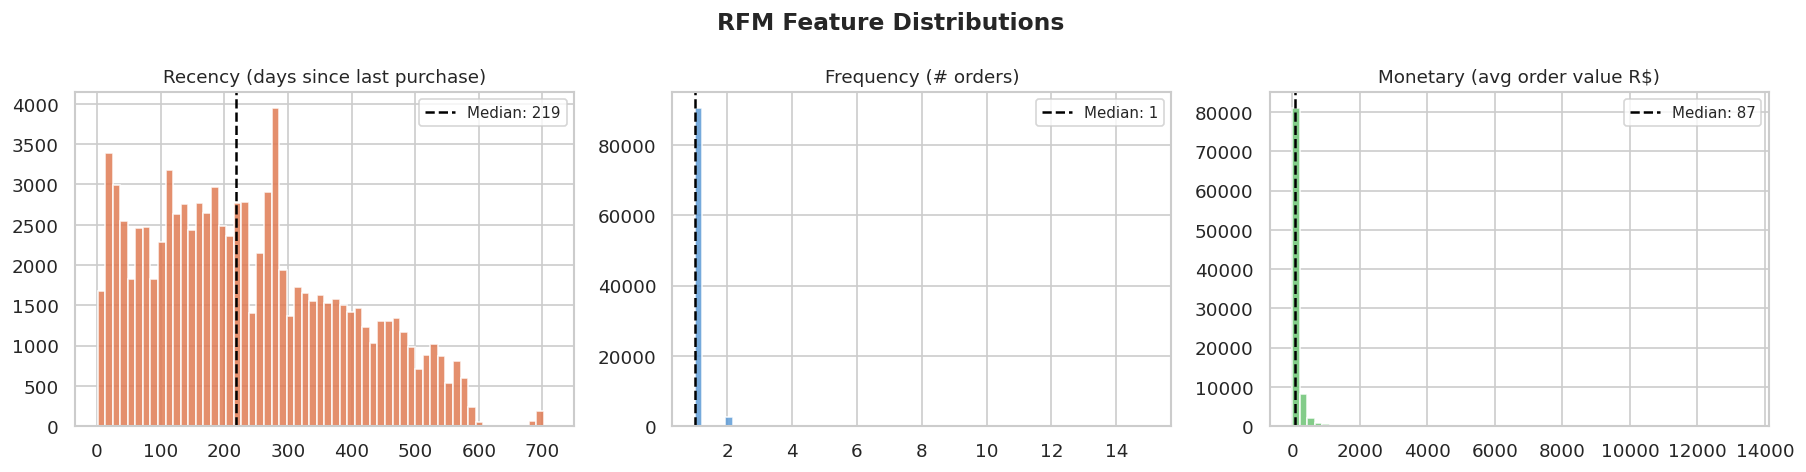


=== RFM Skewness Summary ===
  recency     : skewness = +0.447  (approx. symmetric)
  frequency   : skewness = +11.095  (right-skewed, long upper tail)
  monetary    : skewness = +9.931  (right-skewed, long upper tail)


In [ ]:
# ── RFM distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols  = ['recency', 'frequency', 'monetary']
titles= ['Recency (days since last purchase)',
         'Frequency (# orders)',
         'Monetary (avg order value R$)']
colors= ['#E07B54', '#5E9BD6', '#6DC474']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.hist(rfm[col], bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Skewness summary
print('\n=== RFM Skewness Summary ===')
for col in cols:
    sk = rfm[col].skew()
    direction = '(right-skewed, long upper tail)' if sk > 0.5 else '(left-skewed)' if sk < -0.5 else '(approx. symmetric)'
    print(f'  {col:12s}: skewness = {sk:+.3f}  {direction}')

## Section 6 — RFM Scoring (Percentile Ranking Method)

### Statistical Context

We convert raw RFM values to **scores 1–3** using **percentile-based binning (quantiles)**:

- Percentile ranking is **distribution-agnostic** — it works regardless of skewness.
- We use **tertiles** (33rd / 66th percentile cuts) for three equal-frequency groups.
- **Recency is reversed**: a customer who bought yesterday (low recency days) gets score 3 (best).

In [ ]:
# Percentile-based scoring 1-3
def score_recency(x, quantiles):
    """Lower recency (more recent) → higher score (reversed scale)"""
    if x <= quantiles[0.33]:
        return 3
    elif x <= quantiles[0.66]:
        return 2
    else:
        return 1

def score_fm(x, quantiles):
    """Higher frequency/monetary → higher score (natural scale)"""
    if x <= quantiles[0.33]:
        return 1
    elif x <= quantiles[0.66]:
        return 2
    else:
        return 3

r_q = rfm['recency'].quantile([0.33, 0.66]).to_dict()
f_q = rfm['frequency'].quantile([0.33, 0.66]).to_dict()
m_q = rfm['monetary'].quantile([0.33, 0.66]).to_dict()

rfm['r_score'] = rfm['recency'].apply(lambda x: score_recency(x, r_q))
rfm['f_score'] = rfm['frequency'].apply(lambda x: score_fm(x, f_q))
rfm['m_score'] = rfm['monetary'].apply(lambda x: score_fm(x, m_q))

# ── Overall RFM score (sum of individual scores: range 3–9)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# ── Composite string label (e.g. '332' for r=3, f=3, m=2)
rfm['rfm_label'] = (rfm['r_score'].astype(str) +
                    rfm['f_score'].astype(str) +
                    rfm['m_score'].astype(str))

print('Score distribution:')
print(rfm['rfm_score'].value_counts().sort_index())
rfm[['recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_label']].head(10)

Score distribution:
rfm_score
3    10289
4    20745
5    29632
6    20543
7    11067
8      723
9      359
Name: count, dtype: int64


,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_label
0,112,1,129.90,3,1,3,7,313
1,115,1,18.90,3,1,1,5,311
2,537,1,69.00,1,1,2,4,112
3,321,1,25.99,1,1,1,3,111
4,288,1,180.00,1,1,3,5,113
5,146,1,154.00,3,1,3,7,313
6,132,1,27.99,3,1,1,5,311
7,183,1,382.00,2,1,3,6,213
8,543,1,135.00,1,1,3,5,113
9,170,1,104.90,2,1,2,5,212


### Why 1–3 Scoring ?

The classic RFM literature (Arthur Hughes, 1994) uses **1–5 scoring** (quintiles).  
Many tutorials follow this without questioning whether it fits the dataset.  
Before choosing a scale, we should **look at the actual distributions** — especially frequency.

The core question: **does our data have enough variation to justify 5 meaningful levels?**  
If most customers have the same frequency value, splitting into 5 bins creates artificial precision —  
the difference between score 3 and score 4 would be statistically meaningless.

In [ ]:
# Inspect the raw frequency distribution
freq_counts = rfm['frequency'].value_counts().sort_index()
print('=== Order Frequency Distribution ===')
print(freq_counts.head(15).to_string())
print(f'\nMax frequency: {rfm["frequency"].max()}')
print(f'Mean frequency: {rfm["frequency"].mean():.3f}')
print(f'Median frequency: {rfm["frequency"].median():.0f}')

pct_one_order = (rfm['frequency'] == 1).sum() / len(rfm) * 100
pct_two_orders = (rfm['frequency'] <= 2).sum() / len(rfm) * 100
print(f'\n Customers with exactly 1 order:  {pct_one_order:.1f}%')
print(f' Customers with 1 or 2 orders:    {pct_two_orders:.1f}%')

=== Order Frequency Distribution ===
frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1

Max frequency: 15
Mean frequency: 1.033
Median frequency: 1

 Customers with exactly 1 order:  97.0%
 Customers with 1 or 2 orders:    99.8%


In [ ]:
# Simulate what 1-5 scoring would look like
# What are the actual quintile cut points for frequency?
quintiles = rfm['frequency'].quantile([0.20, 0.40, 0.60, 0.80]).to_dict()
tertiles  = rfm['frequency'].quantile([0.33, 0.66]).to_dict()

print('=== Frequency Quintile Cut Points (for 1-5 scoring) ===')
for q, v in quintiles.items():
    print(f'  {int(q*100)}th percentile: {v:.2f} orders')

print('\n=== Frequency Tertile Cut Points (for 1-3 scoring) ===')
for q, v in tertiles.items():
    print(f'  {int(q*100)}th percentile: {v:.2f} orders')


=== Frequency Quintile Cut Points (for 1-5 scoring) ===
  20th percentile: 1.00 orders
  40th percentile: 1.00 orders
  60th percentile: 1.00 orders
  80th percentile: 1.00 orders

=== Frequency Tertile Cut Points (for 1-3 scoring) ===
  33th percentile: 1.00 orders
  66th percentile: 1.00 orders


In [ ]:
# Map RFM score → Customer Segment
def map_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    score   = row['rfm_score']
    if score >= 8:
        return 'Champions'           # 3-3-x or similar top tier
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent Customers'
    elif r == 2 and f >= 2:
        return 'Potential Loyalists'
    elif r == 1 and f >= 2 and m >= 2:
        return 'At Risk'
    elif r == 1 and m == 3:
        return 'Cannot Lose Them'
    elif score <= 4:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(map_segment, axis=1)

seg_stats = rfm.groupby('segment').agg(
    count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_rfm_score=('rfm_score', 'mean')
).reset_index().sort_values('avg_rfm_score', ascending=False)

seg_stats['% of customers'] = (seg_stats['count'] / seg_stats['count'].sum() * 100).round(1)
seg_stats.round(1)

,segment,count,avg_recency,avg_frequency,avg_monetary,avg_rfm_score,% of customers
2,Champions,1082,117.70,2.10,177.80,8.30,1.20
4,Loyal Customers,259,77.30,2.10,38.30,7.00,0.30
6,Potential Loyalists,636,215.90,2.10,68.50,6.60,0.70
0,At Risk,569,402.10,2.10,156.60,6.50,0.60
7,Recent Customers,29805,75.10,1.00,140.60,6.00,31.90
5,Need Attention,19857,220.90,1.00,182.50,5.50,21.30
1,Cannot Lose Them,10116,415.60,1.00,304.60,5.00,10.80
3,Hibernating,31034,350.30,1.00,51.80,3.70,33.20


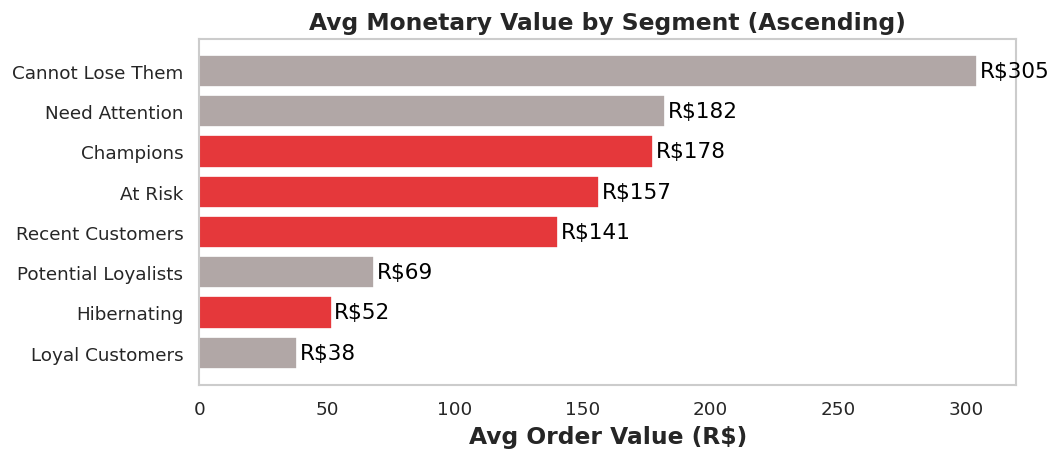


 Business Insight:
   • Champions   → VIP treatment, early access, referral programmes
   • At Risk      → Reactivation campaigns (personalised discount)
   • Hibernating  → Last-chance win-back email (if cost-justified)
   • Recent       → Nurture with onboarding sequence to build loyalty



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort seg_stats by avg_monetary in ascending order for plotting
seg_stats_sorted = seg_stats.sort_values('avg_monetary', ascending=True)

# Define custom colors
highlight_segments = ['Champions', 'At Risk', 'Hibernating', 'Recent Customers']
colors = []
for segment in seg_stats_sorted['segment']:
    if segment in highlight_segments:
        colors.append('#e5383b')
    else:
        colors.append('#b1a7a6')

# Segment visualisation
fig, axes = plt.subplots(figsize=(9, 4))

# Bar chart - avg monetary value per segment
axes.barh(seg_stats_sorted['segment'], seg_stats_sorted['avg_monetary'],
             color=colors)
axes.set_xlabel('Avg Order Value (R$)', fontsize=14, fontweight='bold')
axes.set_title('Avg Monetary Value by Segment (Ascending)', fontsize=14, fontweight='bold')
axes.grid(False) # Exclude background lines
for i, v in enumerate(seg_stats_sorted['avg_monetary']):
    axes.text(v + 1, i, f'R${v:.0f}', va='center', fontsize=13, color='black')

plt.tight_layout()
plt.show()

print('''
 Business Insight:
   • Champions   → VIP treatment, early access, referral programmes
   • At Risk      → Reactivation campaigns (personalised discount)
   • Hibernating  → Last-chance win-back email (if cost-justified)
   • Recent       → Nurture with onboarding sequence to build loyalty
''')

## Section 7 — K-Means Clustering on RFM


In [ ]:
# Feature matrix for clustering
X_rfm = rfm[['recency', 'frequency', 'monetary']].copy()

# Standardise (z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

print('Before scaling:')
print(X_rfm.describe().round(2))
print('\nAfter scaling (mean≈0, std≈1):')
print(pd.DataFrame(X_scaled, columns=X_rfm.columns).describe().round(3))

Before scaling:
       recency  frequency  monetary
count 93358.00   93358.00  93358.00
mean    237.94       1.03    137.51
std     152.59       0.21    209.86
min       1.00       1.00      0.85
25%     114.00       1.00     46.00
50%     219.00       1.00     86.99
75%     346.00       1.00    149.90
max     714.00      15.00  13440.00

After scaling (mean≈0, std≈1):
       recency  frequency  monetary
count 93358.00   93358.00  93358.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -1.55      -0.16     -0.65
25%      -0.81      -0.16     -0.44
50%      -0.12      -0.16     -0.24
75%       0.71      -0.16      0.06
max       3.12      66.80     63.39


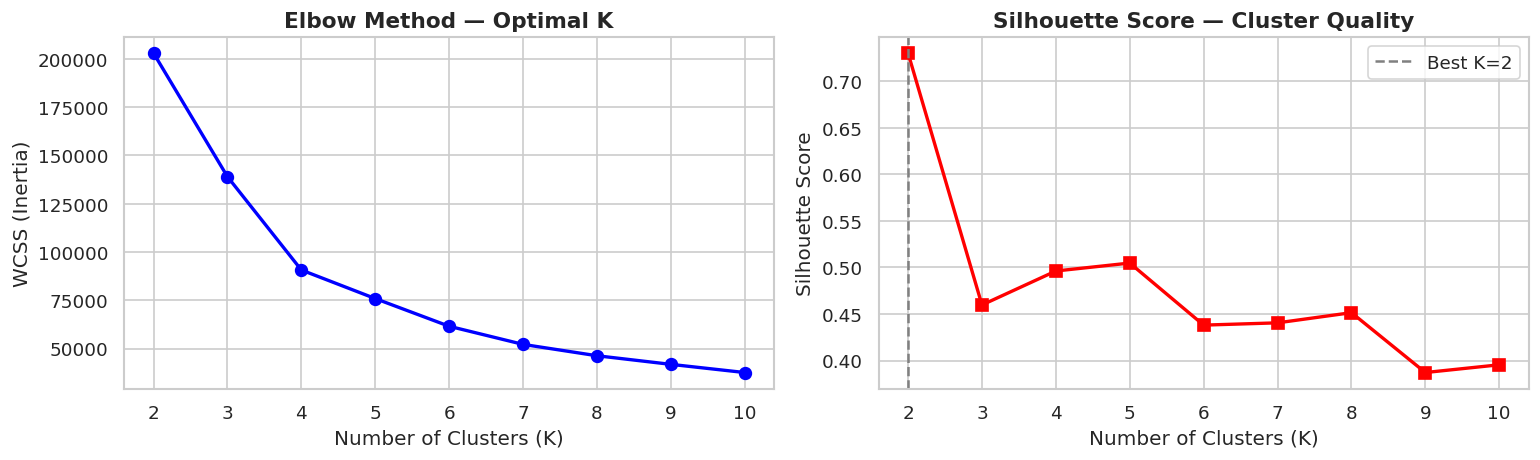

In [ ]:
# ── Elbow Method + Silhouette Scores
K_range = range(2, 11)
wcss_list       = []
silhouette_list = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=15, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_list.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(list(K_range), wcss_list, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(list(K_range), silhouette_list, 'rs-', linewidth=2, markersize=7)
best_k = list(K_range)[silhouette_list.index(max(silhouette_list))]
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Cluster Quality', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()


In [ ]:
print(f'\n Recommended K based on Silhouette: {best_k}')
# Silhouette peaks at K=2 — statistically the cleanest separation.
# However K=2 produces only two segments (active vs inactive),
# which is not granular enough for marketing strategies.
# We select K=4 as the best balance between statistical validity
# (still above 0.3 Silhouette, second best) and business interpretability.



 Recommended K based on Silhouette: 2


In [ ]:
# Fit final K-Means model
OPTIMAL_K = 4  # Adjust based on your elbow/silhouette analysis

km_final = KMeans(n_clusters=OPTIMAL_K, n_init=20, max_iter=500, random_state=42)
rfm['cluster'] = km_final.fit_predict(X_scaled)

# Cluster profile
cluster_profile = (
    rfm.groupby('cluster')
    .agg(
        count=('customer_unique_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        avg_rfm_score=('rfm_score', 'mean')
    )
    .reset_index()
    .sort_values('avg_rfm_score', ascending=False)
)

# Label clusters by avg_rfm_score rank
label_map = {
    cluster_profile.iloc[0]['cluster']: 'High Value',
    cluster_profile.iloc[1]['cluster']: 'Mid Value',
    cluster_profile.iloc[2]['cluster']: 'Low Value',
    cluster_profile.iloc[3]['cluster']: 'Churned / At Risk'
} if OPTIMAL_K == 4 else {}

rfm['cluster_label'] = rfm['cluster'].map(label_map) if label_map else rfm['cluster'].astype(str)

print(cluster_profile.round(2))
print(f'\nSilhouette Score (final model): {silhouette_score(X_scaled, rfm["cluster"]):.4f}')

   cluster  count  avg_recency  avg_frequency  avg_monetary  avg_rfm_score
3        3   2798       220.08           2.11        120.72           7.14
2        2   2483       241.31           1.00       1066.90           5.96
0        0  50776       128.45           1.00        111.85           5.55
1        1  37301       388.10           1.00        111.83           4.16

Silhouette Score (final model): 0.4915


In [ ]:
# 3D Scatter Plot of clusters
fig = px.scatter_3d(
    rfm.sample(min(5000, len(rfm)), random_state=42),
    x='recency', y='frequency', z='monetary',
    color='cluster_label',
    title='K-Means Customer Clusters (3D RFM Space)',
    labels={'recency': 'Recency (days)', 'frequency': 'Frequency', 'monetary': 'Avg Monetary (R$)'},
    opacity=0.6,
    height=550
)
fig.show()

print('''
  Summary:
   • K-Means assigns customers to the nearest centroid using Euclidean distance.
   • Standardisation ensures Recency (0-600 days) doesn't dominate Frequency (1-5).
   • Silhouette score > 0.3 indicates meaningful cluster separation.
''')


  Summary:
   • K-Means assigns customers to the nearest centroid using Euclidean distance.
   • Standardisation ensures Recency (0-600 days) doesn't dominate Frequency (1-5).
   • Silhouette score > 0.3 indicates meaningful cluster separation.



## Section 8 — Clustering Method Comparison: K-Means vs GMM vs DBSCAN vs HDBSCAN

### Why K-Means Alone Is Not Enough

K-Means makes three strong assumptions that are often violated in RFM data:

| Assumption | Reality in RFM |
|---|---|
| Clusters are **spherical** | Champions cluster is tight; Hibernating is diffuse — very different shapes |
| Clusters are **equal-sized** | VIP segment is always a small minority |
| **Hard assignment** — each customer belongs to exactly one cluster | Real customers sit between segments |
| Sensitive to **outliers** | High-value outliers pull centroids and distort all other clusters |

### Algorithms Compared

**Gaussian Mixture Model (GMM)**  
A probabilistic model that assumes data comes from a mixture of K Gaussian distributions.  
Each customer gets a *probability* of belonging to each cluster — not a hard label.  
Fitted by the **EM (Expectation-Maximisation) algorithm**:
- E-step: compute probability of each point belonging to each Gaussian
- M-step: update Gaussian parameters (mean, covariance) to maximise likelihood
- Repeat until convergence



**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)  
Finds clusters as **dense regions** separated by low-density space.  
Two parameters: `eps` (neighbourhood radius) and `min_samples` (minimum points to form a core).  
Points that don't belong to any dense region are labelled **noise (-1)** — these are your outlier customers.  
Does **not require K** to be specified in advance.

**HDBSCAN** (Hierarchical DBSCAN)   
Extracts the most stable clusters from the hierarchy — handles **varying density** far better.  
Only requires `min_cluster_size`. Much more robust on real-world data.

### 📊 Evaluation Metrics

| Metric | Formula (concept) | Best value | Notes |
|--------|-------------------|------------|-------|
| **Silhouette Score** | mean((b−a)/max(a,b)) | Closer to +1 | Measures cohesion vs separation |
| **Calinski-Harabasz Index** | Between-cluster / Within-cluster variance ratio | Higher | Fast to compute, prefers compact clusters |
| **Davies-Bouldin Index** | Avg ratio of within-cluster scatter to between-cluster distance | Lower | Penalises overlapping clusters |
| **BIC** (GMM only) | Penalised log-likelihood | Lower | Balances fit vs model complexity |

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    print('Install hdbscan: pip install hdbscan')
    HDBSCAN_AVAILABLE = False


### 8.1 - Gaussian Mixture Model (GMM)

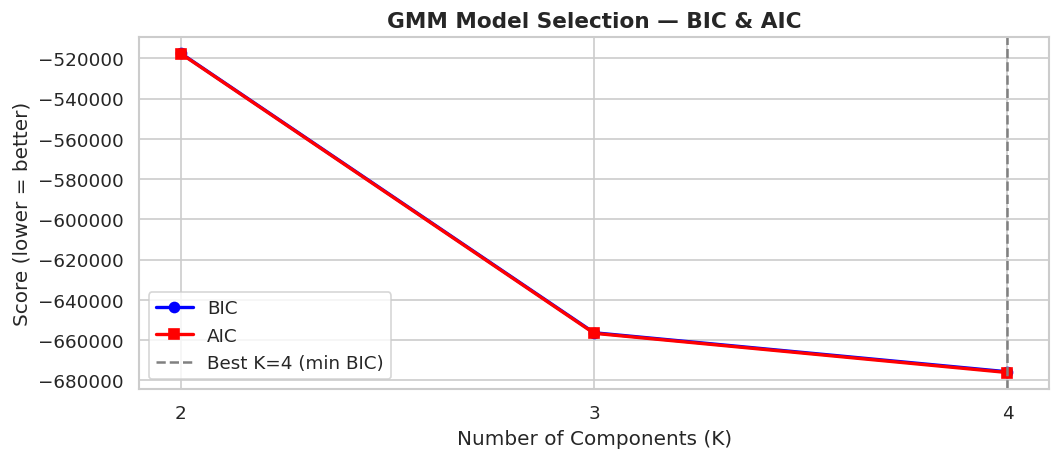

Optimal GMM components (BIC): 4

💡 BIC vs AIC:
   • Both penalise model complexity to prevent overfitting
   • BIC penalises extra parameters more heavily (safer choice)
   • AIC is more lenient — tends to select more components
   • For clustering, prefer BIC: interpretability matters more than fit



In [ ]:
# GMM: find optimal number of components via BIC
# Don't let BIC search beyond what a marketing team can act on
# 3-4 Sweet spot for most marketing teams
# 5-6 Justified only with large datasets and clear profile differences
K_range_gmm = range(2, 5)
bic_scores  = []
aic_scores  = []

for k in K_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

#  Plot BIC / AIC
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range_gmm), bic_scores, 'bo-', label='BIC', linewidth=2)
ax.plot(list(K_range_gmm), aic_scores, 'rs-', label='AIC', linewidth=2)
best_k_gmm = list(K_range_gmm)[bic_scores.index(min(bic_scores))]
ax.axvline(best_k_gmm, color='gray', linestyle='--', label=f'Best K={best_k_gmm} (min BIC)')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM Model Selection — BIC & AIC', fontweight='bold')
ax.legend()
ax.set_xticks(list(K_range_gmm))
plt.tight_layout()
plt.show()

print(f'Optimal GMM components (BIC): {best_k_gmm}')
print('''
💡 BIC vs AIC:
   • Both penalise model complexity to prevent overfitting
   • BIC penalises extra parameters more heavily (safer choice)
   • AIC is more lenient — tends to select more components
   • For clustering, prefer BIC: interpretability matters more than fit
''')

In [ ]:
#  Fit final GMM
#  K-Means assigns segments, GMM measures certainty within those segments.
gmm_final = GaussianMixture(
    n_components=best_k_gmm,
    covariance_type='full',   # each cluster has its own covariance matrix
    n_init=10,
    random_state=42
)
gmm_final.fit(X_scaled)

rfm['gmm_cluster']  = gmm_final.predict(X_scaled)

# Soft membership probabilities (the KEY advantage over K-Means)
gmm_probs = gmm_final.predict_proba(X_scaled)
prob_df = pd.DataFrame(gmm_probs, columns=[f'P(cluster_{i})' for i in range(best_k_gmm)])
prob_df['assigned_cluster'] = rfm['gmm_cluster'].values
prob_df['max_prob']         = gmm_probs.max(axis=1)

print('=== GMM Soft Membership (first 10 customers) ===')
print(prob_df.head(10).round(3))
print(f'\nAverage certainty (max probability): {prob_df["max_prob"].mean():.3f}')
print(f'Customers with certainty < 60%: {(prob_df["max_prob"] < 0.60).sum():,}')
print('''
   Low-certainty customers are genuinely ambiguous — they sit between segments.
   K-Means would force them into one cluster. GMM honestly represents this uncertainty.
   Marketing implication: uncertain customers need A/B testing to determine the right strategy.
''')

=== GMM Soft Membership (first 10 customers) ===
   P(cluster_0)  P(cluster_1)  P(cluster_2)  P(cluster_3)  assigned_cluster  \
0          0.76          0.00          0.01          0.23                 0   
1          0.96          0.00          0.01          0.04                 0   
2          0.89          0.00          0.00          0.11                 0   
3          0.94          0.00          0.00          0.05                 0   
4          0.09          0.00          0.02          0.89                 3   
5          0.44          0.00          0.01          0.54                 3   
6          0.96          0.00          0.00          0.04                 0   
7          0.00          0.00          0.16          0.84                 3   
8          0.46          0.00          0.01          0.53                 3   
9          0.89          0.00          0.00          0.11                 0   

   max_prob  
0      0.76  
1      0.96  
2      0.89  
3      0.94  
4      0.89

GMM Cluster Profiles:
   gmm_cluster  count  avg_recency  avg_frequency  avg_monetary  avg_rfm_score
1            1   2801       220.29           2.11        122.96           7.14
2            2   3976       245.59           1.00        861.45           5.95
3            3  19701       249.28           1.00        229.44           5.93
0            0  66880       234.89           1.00         68.00           4.65


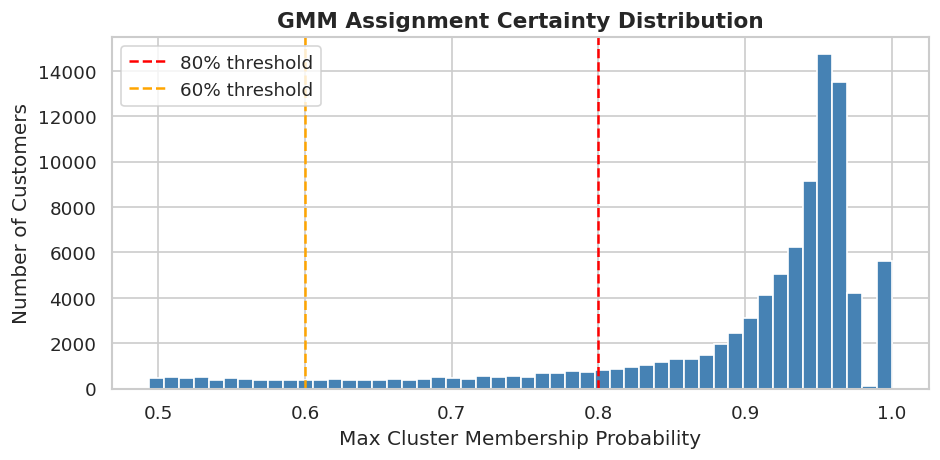

In [ ]:
# GMM cluster profiles
gmm_profile = (
    rfm.groupby('gmm_cluster')
    .agg(
        count=('customer_unique_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        avg_rfm_score=('rfm_score', 'mean')
    )
    .reset_index()
    .sort_values('avg_rfm_score', ascending=False)
)
print('GMM Cluster Profiles:')
print(gmm_profile.round(2))

#  Uncertainty heatmap
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prob_df['max_prob'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(0.8, color='red',    linestyle='--', label='80% threshold')
ax.axvline(0.6, color='orange', linestyle='--', label='60% threshold')
ax.set_xlabel('Max Cluster Membership Probability')
ax.set_ylabel('Number of Customers')
ax.set_title('GMM Assignment Certainty Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 8.2 - DBSCAN: Density-Based Clustering

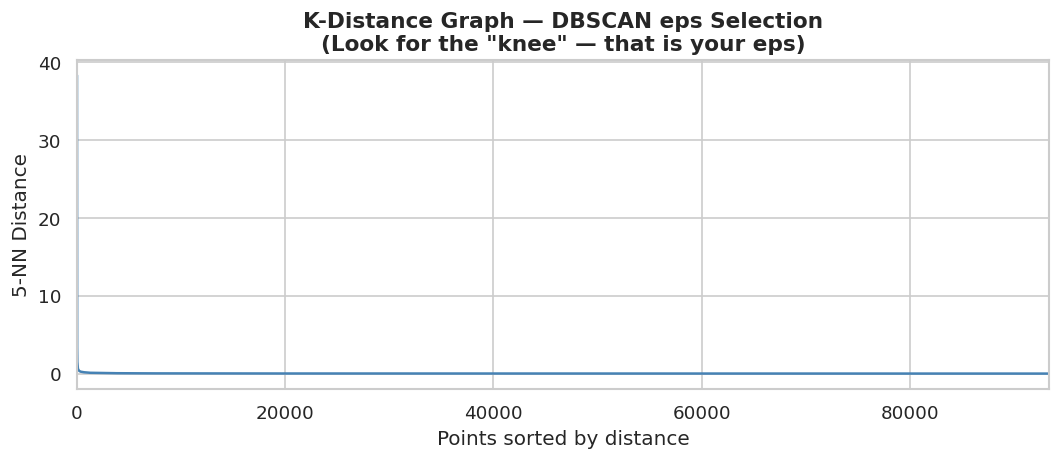


💡 How to read this graph:
   • Sort all points by their distance to the k-th nearest neighbour
   • The "knee" (sharp bend) separates core points from noise
   • Set eps = the y-value at the knee
   • Too small eps → too many noise points; too large → one giant cluster



In [ ]:
# DBSCAN eps selection via k-distance graph
# The 'knee' in the k-nearest-neighbour distance plot suggests a good eps value
from sklearn.neighbors import NearestNeighbors

k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, k_nn - 1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(kth_distances, color='steelblue', linewidth=1.5)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title('K-Distance Graph — DBSCAN eps Selection\n(Look for the "knee" — that is your eps)', fontweight='bold')
ax.set_xlim(0, len(kth_distances))
plt.tight_layout()
plt.show()

print('''
   • Sort all points by their distance to the k-th nearest neighbour
   • The "knee" (sharp bend) separates core points from noise
   • Set eps = the y-value at the knee
   • Too small eps → too many noise points; too large → one giant cluster
''')

In [ ]:
# Why DBSCAN was excluded
# The k-distance graph produced a flat line near zero across all tested
# k values. This indicates no meaningful density variation exists in the
# standardised RFM space — the data forms a continuous cloud rather than
# distinct dense regions separated by empty space.
#
# DBSCAN assumes clusters are separated by low-density corridors.
# RFM data violates this assumption: customer value exists on a spectrum,
# not in isolated islands. StandardScaler further smooths the distribution,
# removing the density contrasts DBSCAN needs to function.
#
#K-Means and GMM are more appropriate algorithms for this data geometry.

# Why CLV Analysis Was Not Performed

**This section intentionally does not contain a CLV prediction model.**

Understanding customer value is crucial for shaping the right business strategies. I initially tried to model Customer Lifetime Value (CLV) for Olist using standard industry assumptions, but I quickly realized a mismatch. Olist's business characteristics didn't align with typical CLV modelling requirements.

- Single Purchase Pattern: I found that over 90% of Olist's customers made only one purchase, which didn't provide the repeat purchase behavior necessary for traditional CLV models.



- Marketplace Model Limitations: Olist operates as a marketplace mainly for furniture and appliances, which don't naturally foster the ongoing customer-business relationships that CLV methods require.

- Low Repeat Purchase Rate: With a low repeat purchase rate of 3-5%, far below the 20-30% needed for robust CLV modelling, I identified that standard models would be unstable and unreliable.
Lack of Observation Window: The absence of a post-dataset